# Figure 2 and S4: modRNA Selectivity in HEK293Ts
Experimental details:
- Seeded 100k 293Ts in 96-well scale
- Transfected 100ng modRNA per condition in triplicate

Reps: All bioreps were seeded from seperately passaged 293Ts
- 2026.06.02 (Bioreps 1,2,3)

**Load in packages**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson

## Loading Data

In [14]:
#Setting paths to flow data and metadata
base_path = rd.datadir/'data'/'attune'/'Derin'
data_path = base_path/'2026.6.03_293T_DASIT_modRNA_mR2-irfp2_selectivity_Biorep1,2,3'/'CSV'
yaml_path = data_path/'wells_metadata.yaml'
output_path = rd.rootdir/'output'/'Figure_2'
output_path_supp = rd.rootdir/'output'/'Figure_S4'

In [15]:
data = pd.DataFrame()
channel_list = ['mRuby2-H', 'iRFP670-H', 'mGL-H', 'TagBFP-H','FSC-A']


cache_path = rd.rootdir/'output'/'Figure_2'/'data_modRNA.gzip'

if cache_path.exists():
    data = pd.read_parquet(rd.outfile(cache_path))
else:
    data = rd.flow.load_csv_with_metadata(data_path, yaml_path, columns=channel_list)
    data.to_parquet(rd.outfile(cache_path))

#Changing the mGL channel name to EGFP for clarity in the analysis
data =data.rename(columns={'mGL-H': 'EGFP-H'})

display(data)

,condition,biorep,well,population,FSC-A,EGFP-H,iRFP670-H,TagBFP-H,mRuby2-H
0,wtNb-mR2-iRFP,2,A10,Single Cells,462558,131,345,178,1084
1,wtNb-mR2-iRFP,2,A10,Single Cells,408567,171,149,216,297
2,wtNb-mR2-iRFP,2,A10,Single Cells,287599,168,237,208,1146
3,wtNb-mR2-iRFP,2,A10,Single Cells,446380,76,80,162,143
4,wtNb-mR2-iRFP,2,A10,Single Cells,429922,168,1520,265,2288
...,...,...,...,...,...,...,...,...,...
1574331,UT,3,H8,Single Cells,365819,149,81,77,119
1574332,UT,3,H8,Single Cells,416571,87,107,192,150
1574333,UT,3,H8,Single Cells,454022,84,124,149,125
1574334,UT,3,H8,Single Cells,493868,92,91,157,55


## Gating

**Untransfected data**

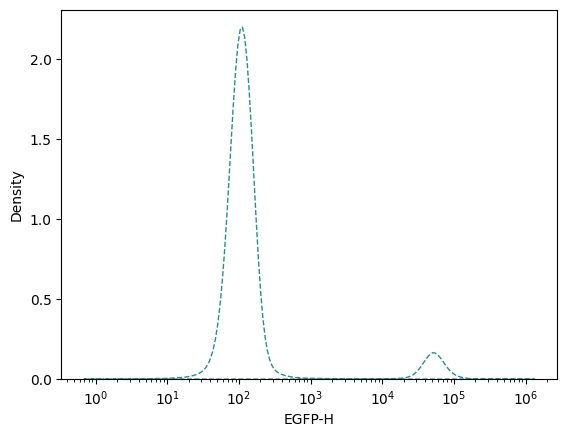

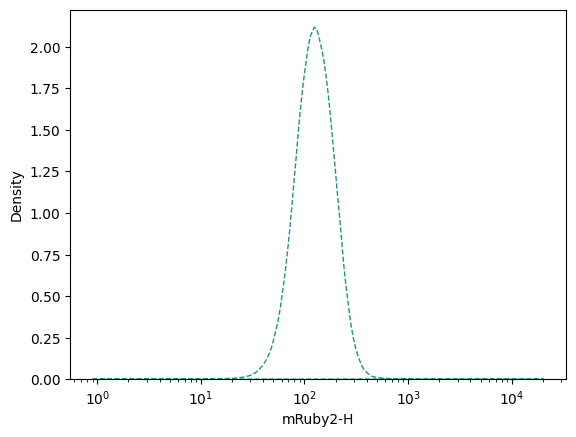

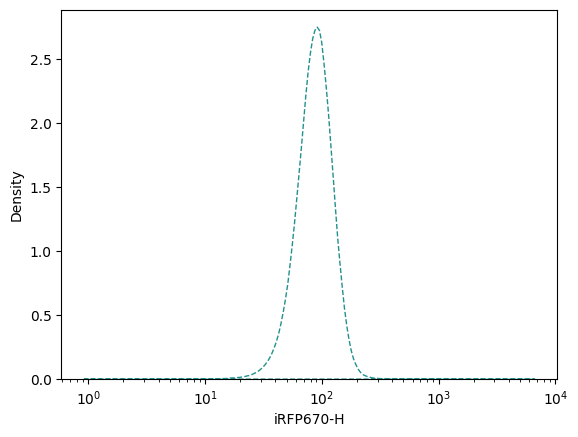

In [4]:
parameters = np.array(['EGFP-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['condition'] == 'UT') & (data[param] > 0 )]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='condition',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

**Setting gates**

In [5]:
untransfected = data[(data['condition'] == 'UT')]
# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-H'].quantile(0.99)
eGFP_gate = 8000
mRuby2_gate = 1000

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-H'] > iRFP_gate_quantile]
data_eGFP = data[data['EGFP-H'] > eGFP_gate]

**Gating for mRuby2 and EGFP**

In [6]:
mRuby2_gated = data[data['mRuby2-H'] > mRuby2_gate].copy()
mRuby2_gated['eGFP_cat'] = np.where(mRuby2_gated['EGFP-H'] > eGFP_gate, 'eGFP+', 'eGFP-') 

In [7]:
well_group = ['condition','biorep']
count_df = mRuby2_gated.groupby(['condition', 'biorep','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_mRuby2 = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_mRuby2 = count_df.reset_index()
display(percent_small_data_1_mRuby2)

,condition,biorep,eGFP_cat,percent
0,Puro,1,eGFP+,56.250000
1,Puro,1,eGFP-,43.750000
2,Puro,2,eGFP+,10.943396
3,Puro,2,eGFP-,89.056604
4,Puro,3,eGFP+,0.000000
5,Puro,3,eGFP-,100.000000
6,UT,1,eGFP+,50.000000
7,UT,1,eGFP-,50.000000
8,UT,2,eGFP+,7.913669
9,UT,2,eGFP-,92.086331


**Stat functions**

In [8]:
# Convert p-value to significance stars
def p_to_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'


# Function for drawing brackets
def add_sig_bracket(ax, x1, x2, y, h, p):
    
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        color='black',
        linewidth=1,
        clip_on=False
    )
    
    ax.text(
        (x1 + x2) / 2,
        y + h,
        p_to_stars(p),
        ha='center',
        va='bottom',
        fontsize=9
    )


## Figure 2C - fluorescent selectivity

**Figure 2C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_16128\2124512751.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_16128\2124512751.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


wtNB vs desNB: t = -19.276, p = 4.269e-05


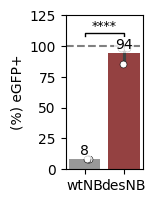

In [9]:
# General plotting params
x = 'condition'
y = 'percent'

# Conditions
order = ['wtNb-mR2-iRFP', 'desNb-mR2-iRFP']
eGFP_cat = 'eGFP+'

df = percent_small_data_1_mRuby2.loc[percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat]

palette = {
    'desNb-mR2-iRFP': 'darkred', 
    'wtNb-mR2-iRFP': 'grey'
}
fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)

# ---------------------------------------------------------
# Statistics: wtNB vs desNB
# ---------------------------------------------------------

from scipy.stats import ttest_ind

wtNB = df.loc[
    df['condition'] == 'wtNb-mR2-iRFP',
    y
].dropna()

desNB = df.loc[
    df['condition'] ==  'desNb-mR2-iRFP',
    y
].dropna()

# Two-sided independent Student's t-test
t_stat, p_val = ttest_ind(
    wtNB,
    desNB,
    equal_var=True,
    alternative='two-sided'
)

print(
    f"wtNB vs desNB: "
    f"t = {t_stat:.3f}, "
    f"p = {p_val:.4g}"
)

# ---------------------------------------------------------
# Add significance bracket
# ---------------------------------------------------------

add_sig_bracket(
    ax,
    0,
    1,
    y=108,
    h=3,
    p=p_val
)

lmap = {
    'wtNb-mR2-iRFP': 'wtNB', 
    'desNb-mR2-iRFP': 'desNB'
}
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 125))
plt.axhline(y=100, color='grey', linestyle= '--')
ax.yaxis.set_label_text('(%) eGFP+')
# ax.set_title('mRuby2+ | 4 dpi (Lenti) | new plasmids')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

plottitle = 'Figure_2C_modRNA.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**Figure 2C (no stats)**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_16128\1311957100.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_16128\1311957100.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


wtNB mean = 8.08%
desNB mean = 94.06%
Fold change (desNB / wtNB) = 11.64x


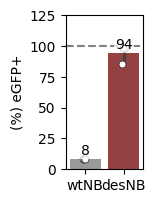

In [10]:
# General plotting params
x = 'condition'
y = 'percent'

# Conditions
order = ['wtNb-mR2-iRFP', 'desNb-mR2-iRFP']
eGFP_cat = 'eGFP+'

df = percent_small_data_1_mRuby2.loc[
    percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat
]

palette = {
    'desNb-mR2-iRFP': 'darkred', 
    'wtNb-mR2-iRFP': 'grey'
}

fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    palette=palette,
    alpha=0.8
)

sns.stripplot(
    ax=ax,
    data=df,
    x=x,
    y=y,
    order=order,
    dodge=True,
    color='white',
    size=5,
    edgecolor='black',
    linewidth=0.4,
)


# ---------------------------------------------------------
# Calculate fold change: desNB / wtNB
# ---------------------------------------------------------

wtNB_mean = df.loc[
    df['condition'] == 'wtNb-mR2-iRFP',
    y
].mean()

desNB_mean = df.loc[
    df['condition'] == 'desNb-mR2-iRFP',
    y
].mean()

fold_change = desNB_mean / wtNB_mean

print(
    f"wtNB mean = {wtNB_mean:.2f}%"
)

print(
    f"desNB mean = {desNB_mean:.2f}%"
)

print(
    f"Fold change (desNB / wtNB) = {fold_change:.2f}x"
)


# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

lmap = {
    'wtNb-mR2-iRFP': 'wtNB', 
    'desNb-mR2-iRFP': 'desNB'
}

ax.set_xticklabels(
    [lmap[cond] for cond in order]
)

ax.set_ylim((0, 125))

plt.axhline(
    y=100,
    color='grey',
    linestyle='--'
)

ax.yaxis.set_label_text('(%) eGFP+')

ax.set_xlabel('')


# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(
            i,
            fmt='%0.0f',
            padding=1
        )

        for label in bar_labels:
            label.set_bbox(
                dict(
                    facecolor='white',
                    alpha=0.75,
                    linewidth=0,
                    pad=1
                )
            )


plottitle = 'Figure_2C_modRNA_no_stats.svg'

plt.savefig(
    rd.outfile(output_path / plottitle),
    bbox_inches='tight'
)

## Contour

**Figure S4C**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_16128\2937185785.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


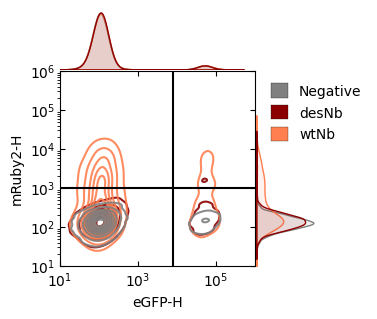

In [11]:
# General plotting params
x = "EGFP-H"
y = "mRuby2-H"
hue = "condition"


hue_order = [ 'desNb-mR2-iRFP','wtNb-mR2-iRFP', 'UT']

# Conditions

palette = {
    'desNb-mR2-iRFP': 'darkred', 
    'wtNb-mR2-iRFP': 'coral',
    'UT': 'grey'
}

# Conditions
data_new = data[(data['EGFP-H'] > 0) & (data['mRuby2-H'] > 0)].copy()
untransfected = data[(data['EGFP-H'] > 0 ) & (data['mRuby2-H'] > 0)]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new, untransfected])
small_data= small_data.groupby('condition').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black',linewidth=0.2,
          label='Negative'),
    Patch(facecolor='darkred', edgecolor='black',linewidth=0.2,
          label='desNb'),
    Patch(facecolor='coral', edgecolor='black', linewidth=0.2,
          label='wtNb')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
ax_scatter.axhline(mRuby2_gate, 0, 1, color='black')
ax_scatter.set_xlabel('eGFP-H')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_S4C_modRNA.svg'
plt.savefig(rd.outfile(output_path_supp/plottitle),bbox_inches='tight')